In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

In [2]:
import sh_ssw_methods as ssw

In [3]:
import numpy as np
import xarray as xr

In [4]:
import importlib as imp

In [5]:
imp.reload(ssw);

- some global variables ...
|

In [6]:
out_dir = 'sh_ssw_methods/processed/'

In [7]:
time_dim ="time"

In [8]:
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)

5. ozone threshold

In [9]:
years = ("1980", "2020")
lat_band=(-90.0,-65.0)
thresh_du=40.0
min_persist_days=3
min_gap_days=20
data_source="MERRA2"

In [10]:
# open sample total column ozone data
tco3_path =  parent_dir + "/data/" +"tco3_MERRA2.nc"
xtco3 = xr.open_dataset(tco3_path)

In [11]:
xtco3

<xarray.Dataset> Size: 5MB
Dimensions:  (time: 16802, lat: 73)
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-07-01 1979-07-02 ... 2025-06-30
  * lat      (lat) float32 292B -90.0 -87.5 -85.0 -82.5 ... 82.5 85.0 87.5 90.0
Data variables:
    tcO3     (time, lat) float32 5MB ...

In [12]:
# select years
da = xtco3['tcO3'].sel(time=slice(*years))

In [13]:
# detect events
tco3_events_df, tco3_dates = ssw.detect_ozone_threshold(da)

In [14]:
tco3_dates

array(['1980-11-26T00:00:00.000000000', '1981-09-21T00:00:00.000000000',
       '1981-11-20T00:00:00.000000000', '1982-10-04T00:00:00.000000000',
       '1983-11-03T00:00:00.000000000', '1984-11-02T00:00:00.000000000',
       '1986-09-05T00:00:00.000000000', '1986-11-13T00:00:00.000000000',
       '1988-09-24T00:00:00.000000000', '1988-10-25T00:00:00.000000000',
       '1991-11-18T00:00:00.000000000', '1994-08-16T00:00:00.000000000',
       '2000-11-06T00:00:00.000000000', '2002-09-22T00:00:00.000000000',
       '2003-11-03T00:00:00.000000000', '2005-11-12T00:00:00.000000000',
       '2012-10-09T00:00:00.000000000', '2013-11-02T00:00:00.000000000',
       '2016-11-23T00:00:00.000000000', '2017-11-07T00:00:00.000000000',
       '2019-09-08T00:00:00.000000000'], dtype='datetime64[ns]')

In [15]:
tco3_events_df

,date,method,definition,data_source,threshold,level_hpa,latitude,lat_band,notes,ozone_onset_DU
0,1980-11-26,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,44.135197
1,1981-09-21,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,41.728470
2,1981-11-20,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,47.080032
3,1982-10-04,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,42.314781
4,1983-11-03,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,41.157120
5,1984-11-02,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,40.721432
6,1986-09-05,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,42.500244
7,1986-11-13,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,45.134018
8,1988-09-24,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,40.411381
9,1988-10-25,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,45.098133


6. u_wind_decel

In [16]:
# open sample total column ozone data
u1060_path =  parent_dir + "/data/" +"u1060s_era5_1959_2023.nc"
xu1060 = xr.open_dataset(u1060_path)

In [17]:
xu1060

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 94964)
Coordinates:
  * time     (time) datetime64[ns] 760kB 1959-01-01 ... 2023-12-31T18:00:00
    lat      float64 8B ...
    plev     float64 8B ...
Data variables:
    u1060S   (time) float32 380kB ...

In [18]:
# select years
da = xu1060['u1060S'].sel(time=slice(*years))
da = da.resample({time_dim: "1D"}).mean()

In [19]:
percentile=90

In [20]:
# detect events
u1060_events_df, u1060_dates = ssw.detect_u_decel_events(da, percentile=percentile)

In [21]:
u1060_dates

DatetimeIndex(['1982-10-11', '1983-10-03', '1983-11-04', '1985-10-07',
               '1988-09-02', '1988-09-29', '1990-09-29', '1991-09-06',
               '1992-10-06', '1993-10-22', '1994-09-17', '1995-10-14',
               '1997-11-07', '2000-10-02', '2002-09-28', '2003-10-12',
               '2005-10-09', '2007-09-21', '2009-10-15', '2012-10-10',
               '2013-10-20', '2014-09-17', '2014-10-12', '2017-09-14',
               '2019-09-04'],
              dtype='datetime64[ns]', freq=None)

In [22]:
u1060_events_df

,date,method,definition,data_source,threshold,level_hpa,latitude,lat_band,notes,drop_val,window_days
0,1982-10-11,u_wind_decel,decel_percentile_90_wdw10_ratio1.2_thr-2.82/day,,-2.824138,None,None,<NA>,; min_gap=20d; window≈10.00d,-30.042351,10.0
1,1983-10-03,u_wind_decel,decel_percentile_90_wdw10_ratio1.2_thr-2.82/day,,-2.824138,None,None,<NA>,; min_gap=20d; window≈10.00d,-29.327171,10.0
2,1983-11-04,u_wind_decel,decel_percentile_90_wdw10_ratio1.2_thr-2.82/day,,-2.824138,None,None,<NA>,; min_gap=20d; window≈10.00d,-33.234482,10.0
3,1985-10-07,u_wind_decel,decel_percentile_90_wdw10_ratio1.2_thr-2.82/day,,-2.824138,None,None,<NA>,; min_gap=20d; window≈10.00d,-31.598831,10.0
4,1988-09-02,u_wind_decel,decel_percentile_90_wdw10_ratio1.2_thr-2.82/day,,-2.824138,None,None,<NA>,; min_gap=20d; window≈10.00d,-34.618355,10.0
5,1988-09-29,u_wind_decel,decel_percentile_90_wdw10_ratio1.2_thr-2.82/day,,-2.824138,None,None,<NA>,; min_gap=20d; window≈10.00d,-39.179878,10.0
6,1990-09-29,u_wind_decel,decel_percentile_90_wdw10_ratio1.2_thr-2.82/day,,-2.824138,None,None,<NA>,; min_gap=20d; window≈10.00d,-46.030037,10.0
7,1991-09-06,u_wind_decel,decel_percentile_90_wdw10_ratio1.2_thr-2.82/day,,-2.824138,None,None,<NA>,; min_gap=20d; window≈10.00d,-28.843788,10.0
8,1992-10-06,u_wind_decel,decel_percentile_90_wdw10_ratio1.2_thr-2.82/day,,-2.824138,None,None,<NA>,; min_gap=20d; window≈10.00d,-30.062557,10.0
9,1993-10-22,u_wind_decel,decel_percentile_90_wdw10_ratio1.2_thr-2.82/day,,-2.824138,None,None,<NA>,; min_gap=20d; window≈10.00d,-29.302975,10.0


7. u_anom

for 50hPa

In [23]:
thres = -11 # -20 for hPa
level_hpa = 50 # 10 hPa
latitude = -60

In [24]:
u5060_path =  parent_dir + "/data/" +"u5060s_era5_1959_2023.nc"
xu5060 = xr.open_dataset(u5060_path)

In [25]:
da = xu5060['u5060S'].sel(time=slice("1979","2020"))

In [26]:
u_daily = da.resample({time_dim: "1D"}).mean()

In [27]:
uanom_events_df, uanom_event_dates = ssw.detect_ssw_u_anom(u_daily, thres=thres, level_hpa=level_hpa, latitude=latitude)

In [28]:
uanom_events_df

,date,method,definition,data_source,threshold,level_hpa,latitude,lat_band,notes
0,1979-10-22,u_anom,u_anom_-11m/s_50hPa_60S,,-11m/s,50,-60,<NA>,at_least_10d_positive_after_ssw; min_gap=20d
1,1980-07-28,u_anom,u_anom_-11m/s_50hPa_60S,,-11m/s,50,-60,<NA>,at_least_10d_positive_after_ssw; min_gap=20d
2,1981-07-28,u_anom,u_anom_-11m/s_50hPa_60S,,-11m/s,50,-60,<NA>,at_least_10d_positive_after_ssw; min_gap=20d
3,1982-10-07,u_anom,u_anom_-11m/s_50hPa_60S,,-11m/s,50,-60,<NA>,at_least_10d_positive_after_ssw; min_gap=20d
4,1985-06-12,u_anom,u_anom_-11m/s_50hPa_60S,,-11m/s,50,-60,<NA>,at_least_10d_positive_after_ssw; min_gap=20d
5,1988-09-25,u_anom,u_anom_-11m/s_50hPa_60S,,-11m/s,50,-60,<NA>,at_least_10d_positive_after_ssw; min_gap=20d
6,1994-05-30,u_anom,u_anom_-11m/s_50hPa_60S,,-11m/s,50,-60,<NA>,at_least_10d_positive_after_ssw; min_gap=20d
7,1995-07-14,u_anom,u_anom_-11m/s_50hPa_60S,,-11m/s,50,-60,<NA>,at_least_10d_positive_after_ssw; min_gap=20d
8,1996-09-14,u_anom,u_anom_-11m/s_50hPa_60S,,-11m/s,50,-60,<NA>,at_least_10d_positive_after_ssw; min_gap=20d
9,1999-06-16,u_anom,u_anom_-11m/s_50hPa_60S,,-11m/s,50,-60,<NA>,at_least_10d_positive_after_ssw; min_gap=20d


8. u_tend

for 50hPa

In [29]:
thres = -19 # -35 for hPa
level_hpa = 50 # 10 hPa
latitude = -60

In [30]:
u_daily = da.resample({time_dim: "1D"}).mean()

In [31]:
utend_events_df, uanom_event_dates = ssw.detect_ssw_u_tend(u_daily, thres=thres, level_hpa=level_hpa, latitude=latitude)

In [32]:
utend_events_df

,date,method,definition,data_source,threshold,level_hpa,latitude,lat_band,notes
0,1982-10-01,u_tend,u_tend_-19m/s_50hPa_60S,,-19m/s,50,-60,<NA>,u_tend < thres at_least_10d; u_tend defined as...
1,1983-10-31,u_tend,u_tend_-19m/s_50hPa_60S,,-19m/s,50,-60,<NA>,u_tend < thres at_least_10d; u_tend defined as...
2,1984-10-29,u_tend,u_tend_-19m/s_50hPa_60S,,-19m/s,50,-60,<NA>,u_tend < thres at_least_10d; u_tend defined as...
3,1985-10-29,u_tend,u_tend_-19m/s_50hPa_60S,,-19m/s,50,-60,<NA>,u_tend < thres at_least_10d; u_tend defined as...
4,1988-10-21,u_tend,u_tend_-19m/s_50hPa_60S,,-19m/s,50,-60,<NA>,u_tend < thres at_least_10d; u_tend defined as...
5,1992-09-26,u_tend,u_tend_-19m/s_50hPa_60S,,-19m/s,50,-60,<NA>,u_tend < thres at_least_10d; u_tend defined as...
6,1992-10-22,u_tend,u_tend_-19m/s_50hPa_60S,,-19m/s,50,-60,<NA>,u_tend < thres at_least_10d; u_tend defined as...
7,1993-10-17,u_tend,u_tend_-19m/s_50hPa_60S,,-19m/s,50,-60,<NA>,u_tend < thres at_least_10d; u_tend defined as...
8,1995-10-07,u_tend,u_tend_-19m/s_50hPa_60S,,-19m/s,50,-60,<NA>,u_tend < thres at_least_10d; u_tend defined as...
9,1997-10-29,u_tend,u_tend_-19m/s_50hPa_60S,,-19m/s,50,-60,<NA>,u_tend < thres at_least_10d; u_tend defined as...


9. polarT

preprocessing

In [33]:
from sh_ssw_methods.preprocessing import (output_polarT_prefiles,
detect_fsw_SH)

In [34]:
temp_sh_era5 = xr.open_dataset('sh_ssw_methods/processed/era5_temp_sh_10hPa_1979_2023.nc')
temp_sh_era5 = temp_sh_era5['var130']

In [35]:
ds_bands, polarT, polarT_anom =  output_polarT_prefiles(temp_sh_era5)

 Found existing file: sh_ssw_methods/processed/Tmid_polar_10hPa_daily_1979_2023_era5.nc
Found existing file: sh_ssw_methods/processed/polarT_10hPa_daily_1979_2023_era5.nc
Found existing file: sh_ssw_methods/processed/polarT_anom_10hPa_daily_1979_2023_era5.nc


In [36]:
fu1060s = '/net/cfc/s2s/rachwu/scripts/sh_ssw_impact/aparc_project/SouthernWarmings_module/data/u1060s_era5_1959_2023.nc'

In [37]:
u1060s = xr.open_dataset(fu1060s)
u1060s_daily = u1060s.resample(time='1D').mean()

In [38]:
fsw = detect_fsw_SH(u1060s_daily,
    save_file=True,
    out_dir="./sh_ssw_methods/processed"
)

Found existing file: sh_ssw_methods/processed/FSW_dates_SH_10hPa_60S_1959_2023_era5.nc


read files

In [39]:
istart_date = '1979-01-01'
iend_date = '2023-12-31'

years = np.arange(1979, 2023+1,1)

In [40]:
Tband_file = "sh_ssw_methods/processed/Tmid_polar_10hPa_daily_1979_2023_era5.nc"
polarT_file = "sh_ssw_methods/processed/polarT_anom_10hPa_daily_1979_2023_era5.nc"
fsw_file = "sh_ssw_methods/processed/FSW_dates_SH_10hPa_60S_1959_2023_era5.nc"

In [41]:
polarT_events_df, polarT_event_dates = ssw.detect_ssw_polarT(Tband_file, polarT_file, fsw_file, istart_date, iend_date)

In [50]:
polarT_events_df

,date,method,definition,data_source,threshold,level_hpa,latitude,lat_band,notes
0,1979-10-01,polar_T1,polar_T1_1.0σ_5d_persist,,1.0σ,None,-80_to_-90_-60_to_-70,<NA>,polar_T1: ≥5d persistence; min_gap=60d
1,1982-10-07,polar_T1,polar_T1_1.0σ_5d_persist,,1.0σ,None,-80_to_-90_-60_to_-70,<NA>,polar_T1: ≥5d persistence; min_gap=60d
2,1984-10-05,polar_T1,polar_T1_1.0σ_5d_persist,,1.0σ,None,-80_to_-90_-60_to_-70,<NA>,polar_T1: ≥5d persistence; min_gap=60d
3,1988-09-26,polar_T1,polar_T1_1.0σ_5d_persist,,1.0σ,None,-80_to_-90_-60_to_-70,<NA>,polar_T1: ≥5d persistence; min_gap=60d
4,1989-10-20,polar_T1,polar_T1_1.0σ_5d_persist,,1.0σ,None,-80_to_-90_-60_to_-70,<NA>,polar_T1: ≥5d persistence; min_gap=60d
5,1991-10-14,polar_T1,polar_T1_1.0σ_5d_persist,,1.0σ,None,-80_to_-90_-60_to_-70,<NA>,polar_T1: ≥5d persistence; min_gap=60d
6,1992-09-30,polar_T1,polar_T1_1.0σ_5d_persist,,1.0σ,None,-80_to_-90_-60_to_-70,<NA>,polar_T1: ≥5d persistence; min_gap=60d
7,1993-10-20,polar_T1,polar_T1_1.0σ_5d_persist,,1.0σ,None,-80_to_-90_-60_to_-70,<NA>,polar_T1: ≥5d persistence; min_gap=60d
8,2000-10-05,polar_T1,polar_T1_1.0σ_5d_persist,,1.0σ,None,-80_to_-90_-60_to_-70,<NA>,polar_T1: ≥5d persistence; min_gap=60d
9,2002-09-21,polar_T1,polar_T1_1.0σ_5d_persist,,1.0σ,None,-80_to_-90_-60_to_-70,<NA>,polar_T1: ≥5d persistence; min_gap=60d


- 6. zeof (review again, since dates are different...)

In [51]:
from sh_ssw_methods.preprocessing import compute_monthly_eof_series

In [52]:
from sh_ssw_methods.preprocessing import output_daily_pc1

In [53]:
gh_file = 'sh_ssw_methods/processed/era5_geopot_10hPa_1979_2023.nc'

In [54]:
gh_era5 = xr.open_dataset(gh_file)
gh_era5 = gh_era5['var129']

In [55]:
da = gh_era5

In [56]:
lv = 1000 # Pa

In [57]:
mons = [6,7,8,9,10,11,12]

In [58]:
compute_monthly_eof_series(da, lv=lv, mons=mons, out_dir=out_dir)

Using level 1000 Pa from data.

Processing month: 06
Existing EOF1 file found: sh_ssw_methods/processed/zeof/ERA5.EOF1.z10.Mon06.nc

Processing month: 07
Existing EOF1 file found: sh_ssw_methods/processed/zeof/ERA5.EOF1.z10.Mon07.nc

Processing month: 08
Existing EOF1 file found: sh_ssw_methods/processed/zeof/ERA5.EOF1.z10.Mon08.nc

Processing month: 09
Existing EOF1 file found: sh_ssw_methods/processed/zeof/ERA5.EOF1.z10.Mon09.nc

Processing month: 10
Existing EOF1 file found: sh_ssw_methods/processed/zeof/ERA5.EOF1.z10.Mon10.nc

Processing month: 11
Existing EOF1 file found: sh_ssw_methods/processed/zeof/ERA5.EOF1.z10.Mon11.nc

Processing month: 12
Existing EOF1 file found: sh_ssw_methods/processed/zeof/ERA5.EOF1.z10.Mon12.nc

All requested months processed.


{6: <xarray.DataArray 'eof1' (lat: 36, lon: 180)> Size: 26kB
 [6480 values with dtype=float32]
 Coordinates:
     mode     int64 8B ...
   * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
   * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0,
 7: <xarray.DataArray 'eof1' (lat: 36, lon: 180)> Size: 26kB
 [6480 values with dtype=float32]
 Coordinates:
     mode     int64 8B ...
   * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
   * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0,
 8: <xarray.DataArray 'eof1' (lat: 36, lon: 180)> Size: 26kB
 [6480 values with dtype=float32]
 Coordinates:
     mode     int64 8B ...
   * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
   * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0,
 9: <xarray.DataArray 'eof1' (lat: 36, lon: 180)> Size: 26kB
 [6480 values with dtype=float32]
 Coordinates:
   

In [59]:
output_daily_pc1(lv, mons, out_dir) # check file exist first


=== Computing PC1 for z10hPa Month 06 ===

=== Computing PC1 for z10hPa Month 07 ===

=== Computing PC1 for z10hPa Month 08 ===

=== Computing PC1 for z10hPa Month 09 ===

=== Computing PC1 for z10hPa Month 10 ===

=== Computing PC1 for z10hPa Month 11 ===

=== Computing PC1 for z10hPa Month 12 ===

 Finished computing PC1 for all requested months.

--- Writing standardized PC1 files for Month 06 ---

--- Writing standardized PC1 files for Month 07 ---

--- Writing standardized PC1 files for Month 08 ---

--- Writing standardized PC1 files for Month 09 ---

--- Writing standardized PC1 files for Month 10 ---

--- Writing standardized PC1 files for Month 11 ---

--- Writing standardized PC1 files for Month 12 ---

 All PC1 text files written successfully.


In [60]:
zeof_events_df, zeof_event_dates = ssw.detect_pc1_events(int(lv/100), thresh=1, basepath=out_dir)

In [61]:
zeof_events_df

,date,method,definition,data_source,threshold,level_hpa,latitude,lat_band,notes
0,1982-06-27,zeof1,EOF1_PC1_gt1.0_10hPa_-20_to_-90,era5,>1.0σ,10,-20_to_-90,<NA>,PC1 > 1.0σ for at least 14 consecutive days; e...
1,1987-08-09,zeof1,EOF1_PC1_gt1.0_10hPa_-20_to_-90,era5,>1.0σ,10,-20_to_-90,<NA>,PC1 > 1.0σ for at least 14 consecutive days; e...
2,1987-10-17,zeof1,EOF1_PC1_gt1.0_10hPa_-20_to_-90,era5,>1.0σ,10,-20_to_-90,<NA>,PC1 > 1.0σ for at least 14 consecutive days; e...
3,1989-07-18,zeof1,EOF1_PC1_gt1.0_10hPa_-20_to_-90,era5,>1.0σ,10,-20_to_-90,<NA>,PC1 > 1.0σ for at least 14 consecutive days; e...
4,1998-11-20,zeof1,EOF1_PC1_gt1.0_10hPa_-20_to_-90,era5,>1.0σ,10,-20_to_-90,<NA>,PC1 > 1.0σ for at least 14 consecutive days; e...
5,1999-11-10,zeof1,EOF1_PC1_gt1.0_10hPa_-20_to_-90,era5,>1.0σ,10,-20_to_-90,<NA>,PC1 > 1.0σ for at least 14 consecutive days; e...
6,2001-06-26,zeof1,EOF1_PC1_gt1.0_10hPa_-20_to_-90,era5,>1.0σ,10,-20_to_-90,<NA>,PC1 > 1.0σ for at least 14 consecutive days; e...
7,2001-12-16,zeof1,EOF1_PC1_gt1.0_10hPa_-20_to_-90,era5,>1.0σ,10,-20_to_-90,<NA>,PC1 > 1.0σ for at least 14 consecutive days; e...
8,2006-08-23,zeof1,EOF1_PC1_gt1.0_10hPa_-20_to_-90,era5,>1.0σ,10,-20_to_-90,<NA>,PC1 > 1.0σ for at least 14 consecutive days; e...
9,2008-08-11,zeof1,EOF1_PC1_gt1.0_10hPa_-20_to_-90,era5,>1.0σ,10,-20_to_-90,<NA>,PC1 > 1.0σ for at least 14 consecutive days; e...


10. STcoupled mode

In [68]:
u_file = "sh_ssw_methods/processed/era5_uwind_all_lv_monthly_1979_2023.nc" # monthly 

In [69]:
xu_era5 = xr.open_dataset(u_file)
xu_era5= xu_era5['uwind']

In [70]:
from sh_ssw_methods.preprocessing import compute_stcmI

In [71]:
compute_stcmI(xu_era5, out_dir)

 File already exists: sh_ssw_methods/processed/stcmI.1979-2023.txt
→ Skipping computation. To recompute, delete the file first.


In [72]:
stcmI_file = "sh_ssw_methods/processed/stcmI.1979-2023.txt"

In [73]:
stm_events_df, stm_event_years = ssw.detect_stmi_events(stcmI_file)

In [74]:
stm_events_df

,date,method,definition,data_source,threshold,level_hpa,latitude,lat_band,notes,mask
0,1979-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,weak
1,1987-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,strong
2,1988-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,weak
3,1998-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,strong
4,1999-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,strong
5,2000-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,weak
6,2001-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,strong
7,2002-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,weak
8,2005-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,weak
9,2006-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,strong


all data frame


In [93]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Assuming your dataframes are in a list called df_list
# df_list = [df1, df2, df3, ...]
# full_df = pd.concat(df_list).reset_index(drop=True)

# Preprocessing: Ensure 'date' is in datetime format
# full_df['date'] = pd.to_datetime(full_df['date'])

def plot_method_timeline(df):
    plt.figure(figsize=(14, 6))
    
    # Identify unique methods to create y-axis positions
    methods = df['method'].unique()
    method_to_y = {method: i for i, method in enumerate(methods)}
    
    
    # Plotting each event as a vertical line
    for method in methods:
        subset = df[df['method'] == method]
        y_pos = method_to_y[method]
        
        for _, row in subset.iterrows():
            # Get color based on 'mask' value, default to black if not found
            color = 'C0'
            
            # Draw a vertical line segment centered on the method's y-index
            plt.vlines(row['date'], y_pos - 0.3, y_pos + 0.3, 
                       colors=color, linewidth=2, alpha=0.8)
            
    # Styling the plot
    plt.yticks(range(len(methods)), methods)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Method Name', fontsize=12)
    plt.title('southern warming dates', fontsize=14)
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('southern_warming_dates.png', dpi=300)
    plt.show()

# Example usage:
# plot_method_timeline(full_df)

In [94]:
full_df = pd.concat([tco3_events_df, u1060_events_df, uanom_events_df, utend_events_df, polarT_events_df, zeof_events_df,stm_events_df])

In [95]:
full_df

,date,method,definition,data_source,threshold,level_hpa,latitude,lat_band,notes,ozone_onset_DU,drop_val,window_days,mask
0,1980-11-26,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,44.135197,NaN,NaN,NaN
1,1981-09-21,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,41.728470,NaN,NaN,NaN
2,1981-11-20,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,47.080032,NaN,NaN,NaN
3,1982-10-04,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,42.314781,NaN,NaN,NaN
4,1983-11-03,ozone_threshold,ozone_du40_-90to-65S,,40.0DU,None,None,"[-90.0, -65.0]",min_persist=3d; min_gap=20d,41.157120,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,2018-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,NaN,NaN,NaN,strong
17,2019-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,NaN,NaN,NaN,weak
18,2020-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,NaN,NaN,NaN,strong
19,2021-01-01,STCMI,STCMI_±0.8σ,ERA5,±0.8σ,None,None,<NA>,STCMI weak/strong events following Lim et al. ...,NaN,NaN,NaN,strong


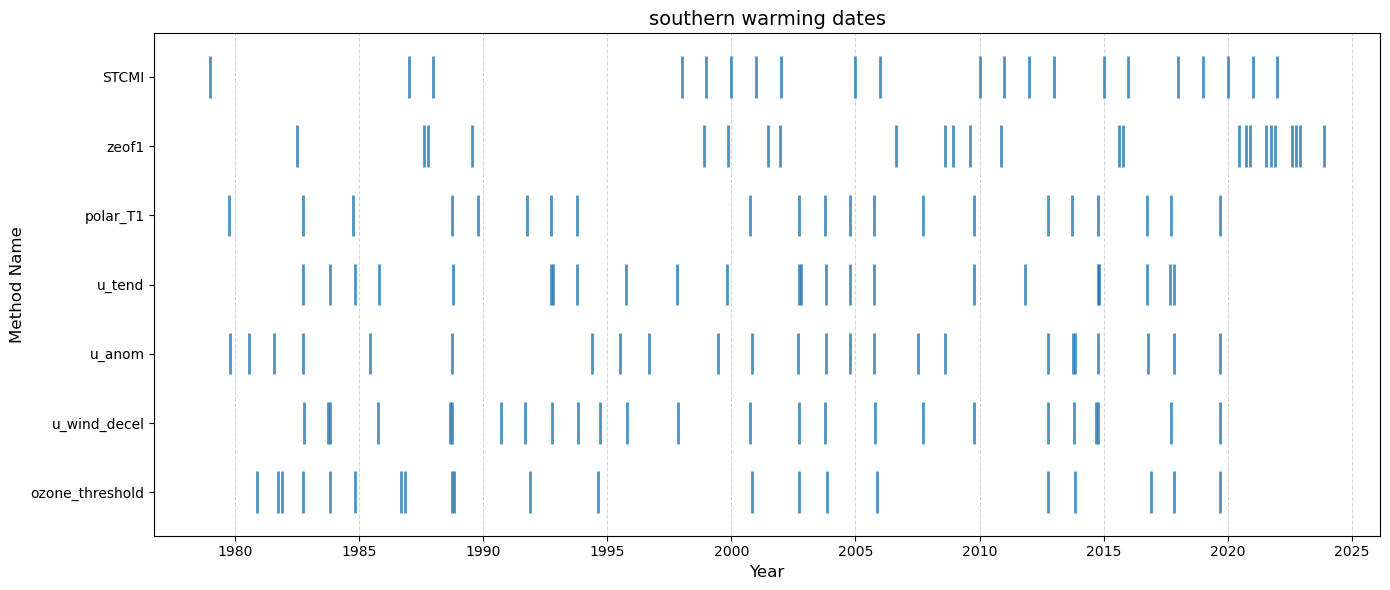

In [96]:
plot_method_timeline(full_df)